python -m venv venv_stat_app
python -m ipykernel install --user --name=venv_stat_app --display-name "Python (stat_app)"

In [21]:
# !pip install --upgrade pip

# !pip install datasets evaluate transformers accelerate
# !pip install torch
# !pip install transformers[torch]
# !pip install scikit-learn
# !pip install matplotlib
# !pip install tqdm

# JIGSAW


## LOADING

## PREPROCESSING

In [ ]:
import os
import pandas as pd
import numpy as np

# =====================================================================
# 1. CONFIGURATION GLOBALE ET ARBORESCENCE DES DOSSIERS
# =====================================================================
DOSSIER_MERE = "INLP_Experiments"
DOSSIER_LIAR = f"{DOSSIER_MERE}/LIAR_data"

# Décommentez simplement la ligne que vous souhaitez étudier !
# target_cols, suffix, nom_categorie = ['male', 'female', 'transgender', 'other_gender'], "gender", "Le Genre"
target_cols, suffix, nom_categorie = ['christian', 'jewish', 'muslim', 'hindu', 'buddhist', 'atheist', 'other_religion'], "religion", "La Religion"
# target_cols, suffix, nom_categorie = ['heterosexual', 'homosexual_gay_or_lesbian', 'bisexual', 'other_sexual_orientation'], "orientation", "L'Orientation Sexuelle"
# target_cols, suffix, nom_categorie = ['physical_disability', 'intellectual_or_learning_disability', 'psychiatric_or_mental_illness', 'other_disability'], "disability", "Le Handicap"
# target_cols, suffix, nom_categorie = ['black', 'white', 'asian', 'latino', 'other_race_or_ethnicity'], "race", "La Race"

# Dossier spécifique à l'attribut en cours
DOSSIER_ATTRIBUT = f"{DOSSIER_MERE}/{suffix}"

# Création des dossiers (exist_ok=True empêche les erreurs si le dossier existe déjà)
os.makedirs(DOSSIER_LIAR, exist_ok=True)
os.makedirs(DOSSIER_ATTRIBUT, exist_ok=True)

print(f"Architecture prête :")
print(f" 📂 {DOSSIER_MERE}/")
print(f" ┣━ 📂 LIAR_data/      <- Vecteurs Fake News")
print(f" ┗━ 📂 {suffix}/          <- Matrices, graphiques et vecteurs pour {nom_categorie}")

Architecture prête :
 📂 INLP_Experiments/
 ┣━ 📂 LIAR_data/      <- Vecteurs Fake News
 ┗━ 📂 race/          <- Matrices, graphiques et vecteurs pour La Race


In [23]:
# 2. Charger Jigsaw (Seulement les colonnes nécessaires)
cols_to_keep = ['comment_text'] + target_cols
df_jigsaw = pd.read_csv('/home/onyxia/work/Stat_App/Data/JIGSAW/all_data.csv', usecols=cols_to_keep)

# Nettoyer les valeurs nulles
df_jigsaw = df_jigsaw.dropna(subset=target_cols)

# 3. Créer les masques dynamiquement
masks = {}
for col in target_cols:
    mask = (df_jigsaw[col] >= 0.5) # La classe principale doit être >= 0.5
    for other_col in target_cols:
        if other_col != col:
            mask = mask & (df_jigsaw[other_col] < 0.5) # Toutes les autres strictement < 0.5
    masks[col] = mask

combined_mask = np.logical_or.reduce(list(masks.values()))
df_filtered = df_jigsaw[combined_mask].copy()

# 4. Assigner l'ID de la classe automatiquement (0, 1, 2...)
col_to_id = {col: i for i, col in enumerate(target_cols)}
conditions = [masks[col][combined_mask] for col in target_cols]
choices = [col_to_id[col] for col in target_cols]

df_filtered['z'] = np.select(conditions, choices, default=-1)

print(f"\nNombre total de textes conservés : {len(df_filtered)}")
print("Répartition :")
for col, z_id in col_to_id.items():
    print(f" - {col} (Classe {z_id}) : {(df_filtered['z'] == z_id).sum()} textes")

texts_jigsaw = df_filtered['comment_text'].tolist()
z_jigsaw = df_filtered['z'].values


Nombre total de textes conservés : 35008
Répartition :
 - black (Classe 0) : 9353 textes
 - white (Classe 1) : 20311 textes
 - asian (Classe 2) : 3920 textes
 - latino (Classe 3) : 1236 textes
 - other_race_or_ethnicity (Classe 4) : 188 textes


## CLS

In [24]:
import torch
import numpy as np
from transformers import AutoTokenizer, AutoModel
from tqdm.auto import tqdm # Pour avoir une jolie barre de progression

# 1. Configuration du modèle et du matériel (GPU si possible, sinon CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Utilisation de l'appareil : {device}")

# On charge la version de base de BERT (sans tête de classification, juste le corps)
model_name = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name).to(device)

# On met le modèle en mode "évaluation" (désactive certaines fonctions d'entraînement comme le Dropout)
model.eval()

# 2. Fonction pour extraire les embeddings par lots (batches)
def get_bert_cls_embeddings(texts, batch_size=32):
    all_embeddings = []
    for i in tqdm(range(0, len(texts), batch_size), desc="Extraction BERT"):
        batch_texts = texts[i : i + batch_size]
        
        inputs = tokenizer(
            batch_texts, 
            padding=True, 
            truncation=True, 
            max_length=128, 
            return_tensors="pt"
        ).to(device)
        
        with torch.no_grad():
            outputs = model(**inputs)
            
        cls_embeddings = outputs.last_hidden_state[:, 0, :]
        all_embeddings.append(cls_embeddings.cpu().numpy())
        
    return np.vstack(all_embeddings)

# 3. Exécution sur vos textes Jigsaw (récupérés à l'étape précédente)
print("Début de l'extraction des vecteurs...")
X_jigsaw = get_bert_cls_embeddings(texts_jigsaw, batch_size=32)

print(f"Forme finale de la matrice X : {X_jigsaw.shape}")
# Devrait afficher (N, 768) où N est le nombre de textes et 768 la taille d'un vecteur BERT

np.save(f"{DOSSIER_ATTRIBUT}/jigsaw_bert_cls_{suffix}.npy", X_jigsaw)
np.save(f"{DOSSIER_ATTRIBUT}/jigsaw_labels_z_{suffix}.npy", z_jigsaw)

print(f"Sauvegarde terminée : 'jigsaw_bert_cls_{suffix}.npy' et 'jigsaw_labels_z_{suffix}.npy'")

Utilisation de l'appareil : cuda


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Début de l'extraction des vecteurs...


Extraction BERT:   0%|          | 0/1094 [00:00<?, ?it/s]

Forme finale de la matrice X : (35008, 768)
Sauvegarde terminée : 'jigsaw_bert_cls_race.npy' et 'jigsaw_labels_z_race.npy'


# LIAR

## LOADING

In [26]:
from datasets import load_dataset
import csv

col_names = [
    "id", "label_text", "statement", "subject", "speaker", 
    "job_title", "state_info", "party_affiliation", 
    "barely_true_counts", "false_counts", "half_true_counts", 
    "mostly_true_counts", "pants_on_fire_counts", "context"
]

raw_datasets = load_dataset(
    "csv", 
    data_files={
        "train": "/home/onyxia/work/Stat_App/Data/LIAR/train.tsv", 
        "validation": "/home/onyxia/work/Stat_App/Data/LIAR/valid.tsv", 
        "test": "/home/onyxia/work/Stat_App/Data/LIAR/test.tsv"
    }, 
    delimiter="\t", 
    column_names=col_names,
    quoting=csv.QUOTE_NONE
)

label_mapping = {
    'pants-fire': 0, 
    'false': 1, 
    'barely-true': 2, 
    'half-true': 3, 
    'mostly-true': 4, 
    'true': 5
}

def map_labels(example):
    return {'label': label_mapping[example['label_text']]}

raw_datasets = raw_datasets.map(map_labels)

print(raw_datasets)

DatasetDict({
    train: Dataset({
        features: ['id', 'label_text', 'statement', 'subject', 'speaker', 'job_title', 'state_info', 'party_affiliation', 'barely_true_counts', 'false_counts', 'half_true_counts', 'mostly_true_counts', 'pants_on_fire_counts', 'context', 'label'],
        num_rows: 10269
    })
    validation: Dataset({
        features: ['id', 'label_text', 'statement', 'subject', 'speaker', 'job_title', 'state_info', 'party_affiliation', 'barely_true_counts', 'false_counts', 'half_true_counts', 'mostly_true_counts', 'pants_on_fire_counts', 'context', 'label'],
        num_rows: 1284
    })
    test: Dataset({
        features: ['id', 'label_text', 'statement', 'subject', 'speaker', 'job_title', 'state_info', 'party_affiliation', 'barely_true_counts', 'false_counts', 'half_true_counts', 'mostly_true_counts', 'pants_on_fire_counts', 'context', 'label'],
        num_rows: 1283
    })
})


## CLS

In [27]:
import numpy as np

# 1. Extraire les listes de textes et de labels de l'objet Hugging Face (LIAR)
print("Préparation des listes de textes LIAR...")
texts_liar_train = raw_datasets["train"]["statement"]
y_liar_train = raw_datasets["train"]["label"]

texts_liar_test = raw_datasets["test"]["statement"]
y_liar_test = raw_datasets["test"]["label"]

# 2. Convertir les textes en vecteurs BERT (Cela prendra quelques minutes)
print("\nExtraction des embeddings pour LIAR (Train)...")
X_liar_train = get_bert_cls_embeddings(texts_liar_train, batch_size=32)

print("\nExtraction des embeddings pour LIAR (Test)...")
X_liar_test = get_bert_cls_embeddings(texts_liar_test, batch_size=32)

# Vérification des dimensions
print(f"\nForme de X_train (LIAR) : {X_liar_train.shape}")
print(f"Forme de X_test (LIAR)  : {X_liar_test.shape}")

# 3. Sauvegarder les vecteurs LIAR dans leur dossier dédié
np.save(f"{DOSSIER_LIAR}/liar_train_bert_cls.npy", X_liar_train)
np.save(f"{DOSSIER_LIAR}/liar_train_labels.npy", y_liar_train)
np.save(f"{DOSSIER_LIAR}/liar_test_bert_cls.npy", X_liar_test)
np.save(f"{DOSSIER_LIAR}/liar_test_labels.npy", y_liar_test)

print(f"\nSauvegarde terminée dans le dossier {DOSSIER_LIAR}/")

print("\nSauvegarde terminée ! Les données LIAR sont vectorisées.")

Préparation des listes de textes LIAR...

Extraction des embeddings pour LIAR (Train)...


Extraction BERT:   0%|          | 0/321 [00:00<?, ?it/s]


Extraction des embeddings pour LIAR (Test)...


Extraction BERT:   0%|          | 0/41 [00:00<?, ?it/s]


Forme de X_train (LIAR) : (10269, 768)
Forme de X_test (LIAR)  : (1283, 768)

Sauvegarde terminée dans le dossier INLP_Experiments/LIAR_data/

Sauvegarde terminée ! Les données LIAR sont vectorisées.


# INLP

In [ ]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import debias 
import warnings
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)

# 1. Charger les vecteurs et labels (Dynamique)
X_jigsaw = np.load(f"{DOSSIER_ATTRIBUT}/jigsaw_bert_cls_{suffix}.npy")
z_jigsaw = np.load(f"{DOSSIER_ATTRIBUT}/jigsaw_labels_z_{suffix}.npy")

# 2. Séparer en Train et Test
X_train_jigsaw, X_dev_jigsaw, z_train_jigsaw, z_dev_jigsaw = train_test_split(
    X_jigsaw, z_jigsaw, test_size=0.2, random_state=42, stratify=z_jigsaw 
)

# 3. Paramétrage dynamique de l'Adversaire et du point d'arrêt
num_classes = len(np.unique(z_jigsaw))
hasard = 1.0 / num_classes
min_acc_dynamic = hasard + 0.02 # Le hasard + 2% de marge

clf = LogisticRegression
clf_params = {'fit_intercept': True, 'class_weight': 'balanced', 'solver': 'lbfgs', 'max_iter': 100}

# 4. APPEL DE LA FONCTION INLP
P_matrix, row_space_projections, Ws = debias.get_debiasing_projection(
    classifier_class=clf,
    cls_params=clf_params,
    num_classifiers=25,
    input_dim=768,
    is_autoregressive=True,
    min_accuracy=min_acc_dynamic,  # <-- S'arrête tout seul au bon moment !
    X_train=X_train_jigsaw, Y_train=z_train_jigsaw,
    X_dev=X_dev_jigsaw, Y_dev=z_dev_jigsaw,
    by_class=False
)

# 5. SAUVEGARDE COMPLÈTE (Dynamique)
np.save(f"{DOSSIER_ATTRIBUT}/projection_matrix_{suffix}.npy", P_matrix)
np.save(f"{DOSSIER_ATTRIBUT}/row_space_projections_{suffix}.npy", np.array(row_space_projections))
np.save(f"{DOSSIER_ATTRIBUT}/Ws_{suffix}.npy", np.array(Ws, dtype=object))

In [28]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# =====================================================================
# 1. Chargement des données LIAR et de la matrice INLP
# =====================================================================
print("Chargement des données en mémoire...")

# NOUVEAU : On ajoute bien DOSSIER_LIAR/ pour trouver les données
X_train_liar = np.load(f"{DOSSIER_LIAR}/liar_train_bert_cls.npy")
y_train_liar = np.load(f"{DOSSIER_LIAR}/liar_train_labels.npy")

X_test_liar = np.load(f"{DOSSIER_LIAR}/liar_test_bert_cls.npy")
y_test_liar = np.load(f"{DOSSIER_LIAR}/liar_test_labels.npy")

# NOUVEAU : On ajoute bien DOSSIER_ATTRIBUT/ pour trouver la matrice
P_matrix = np.load(f"{DOSSIER_ATTRIBUT}/projection_matrix_{suffix}.npy")

# =====================================================================
# EXPÉRIENCE 1 : Détection de Fake News SANS débiaisage (Baseline)
# =====================================================================
print("\n--- ÉTAPE 1 : Entraînement du modèle de base (BIAISÉ) ---")
clf_baseline = LogisticRegression(max_iter=1000, class_weight='balanced')
clf_baseline.fit(X_train_liar, y_train_liar)

y_pred_baseline = clf_baseline.predict(X_test_liar)
acc_baseline = accuracy_score(y_test_liar, y_pred_baseline)
print(f"Accuracy de base : {acc_baseline:.4f}")

# =====================================================================
# L'APPLICATION DE L'INLP (Le Nettoyage)
# =====================================================================
print(f"\n--- ÉTAPE 2 : Application de l'INLP (Effacement : {nom_categorie}) ---")
# On projette les vecteurs dans l'espace nul pour les rendre "aveugles" à cet attribut
X_train_debiased = P_matrix.dot(X_train_liar.T).T
X_test_debiased = P_matrix.dot(X_test_liar.T).T

# =====================================================================
# EXPÉRIENCE 2 : Détection de Fake News AVEC débiaisage
# =====================================================================
print("\n--- ÉTAPE 3 : Entraînement du modèle DÉBIAISÉ ---")
clf_debiased = LogisticRegression(max_iter=1000, class_weight='balanced')
clf_debiased.fit(X_train_debiased, y_train_liar)

y_pred_debiased = clf_debiased.predict(X_test_debiased)
acc_debiased = accuracy_score(y_test_liar, y_pred_debiased)
print(f"Accuracy après débiaisage INLP : {acc_debiased:.4f}")

# =====================================================================
# CONCLUSION DE L'EXPÉRIENCE
# =====================================================================
print("\n--- RÉSULTAT FINAL ---")
diff = acc_baseline - acc_debiased

if diff > 0:
    print(f"L'accuracy a baissé de {diff*100:.2f} points de pourcentage.")
    print(f"Conclusion : Le modèle s'appuyait secrètement sur {nom_categorie} pour détecter les Fake News. En effaçant cette dimension, on a rendu le modèle plus éthique, au prix d'une légère baisse de performance globale.")
else:
    print(f"L'accuracy est restée stable (différence de {-diff*100:.2f} points).")
    print(f"Conclusion : L'effacement du concept ({nom_categorie}) n'a pas dégradé la tâche principale. Le modèle est plus robuste éthiquement sans perte de performance.")

Chargement des données en mémoire...

--- ÉTAPE 1 : Entraînement du modèle de base (BIAISÉ) ---
Accuracy de base : 0.2502

--- ÉTAPE 2 : Application de l'INLP (Effacement : La Race) ---

--- ÉTAPE 3 : Entraînement du modèle DÉBIAISÉ ---
Accuracy après débiaisage INLP : 0.2510

--- RÉSULTAT FINAL ---
L'accuracy est restée stable (différence de 0.08 points).
Conclusion : L'effacement du concept (La Race) n'a pas dégradé la tâche principale. Le modèle est plus robuste éthiquement sans perte de performance.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from tqdm.auto import tqdm
import scipy.linalg

# =====================================================================
# 1. CHARGEMENT DES DONNÉES ET DES RÉSULTATS INLP
# =====================================================================
print("Chargement des données en mémoire...")

# A. Les données LIAR
X_train_liar = np.load(f"{DOSSIER_LIAR}/liar_train_bert_cls.npy")
y_train_liar = np.load(f"{DOSSIER_LIAR}/liar_train_labels.npy")
X_test_liar = np.load(f"{DOSSIER_LIAR}/liar_test_bert_cls.npy")
y_test_liar = np.load(f"{DOSSIER_LIAR}/liar_test_labels.npy")

# B. Les données Jigsaw (Chargement dynamique)
X_jigsaw = np.load(f"{DOSSIER_ATTRIBUT}/jigsaw_bert_cls_{suffix}.npy")
z_jigsaw = np.load(f"{DOSSIER_ATTRIBUT}/jigsaw_labels_z_{suffix}.npy") 
X_train_jigsaw, X_dev_jigsaw, z_train_jigsaw, z_dev_jigsaw = train_test_split(
    X_jigsaw, z_jigsaw, test_size=0.2, random_state=42, stratify=z_jigsaw 
)

# C. Les étapes sauvegardées de l'INLP
row_space_projections = np.load(f"{DOSSIER_ATTRIBUT}/row_space_projections_{suffix}.npy", allow_pickle=True)

# =====================================================================
# 2. RECONSTRUCTION DES MATRICES INTERMÉDIAIRES (Formule de Ben-Israel)
# =====================================================================
print("Calcul des matrices intermédiaires (Formule robuste)...")
input_dim = X_train_jigsaw.shape[1]
P_intermediates = [np.eye(input_dim)] # Itération 0 (Aucun effacement)

# On utilise la somme des espaces de lignes (Q) au lieu de multiplier les P
for k in range(1, len(row_space_projections) + 1):
    Q = np.sum(row_space_projections[:k], axis=0)
    
    if np.allclose(Q, 0):
        P_W = np.zeros_like(Q)
    else:
        # Calcul de la base orthogonale exacte (identique à debias.py)
        w_basis = scipy.linalg.orth(Q.T) 
        P_W = w_basis.dot(w_basis.T)
        
    P_step = np.eye(input_dim) - P_W
    P_intermediates.append(P_step)

# =====================================================================
# ASTUCE D'ACCÉLÉRATION : SOUS-ÉCHANTILLONNAGE POUR L'ÉVALUATION
# =====================================================================
print("Sous-échantillonnage pour une évaluation ultra-rapide...")
n_samples_jig = min(5000, X_train_jigsaw.shape[0])
idx_jig = np.random.choice(X_train_jigsaw.shape[0], n_samples_jig, replace=False)
X_train_jigsaw_fast = X_train_jigsaw[idx_jig]
z_train_jigsaw_fast = z_train_jigsaw[idx_jig]

n_samples_liar = min(5000, X_train_liar.shape[0])
idx_liar = np.random.choice(X_train_liar.shape[0], n_samples_liar, replace=False)
X_train_liar_fast = X_train_liar[idx_liar]
y_train_liar_fast = y_train_liar[idx_liar]

# =====================================================================
# 3. ÉVALUATION RAPIDE À CHAQUE ÉTAPE
# =====================================================================
acc_jigsaw_list = []
acc_liar_list = []

print(f"Évaluation sur {len(P_intermediates)} étapes...")

for P_step in tqdm(P_intermediates):
    
    X_jig_train_proj_fast = X_train_jigsaw_fast.dot(P_step)
    X_jig_dev_proj        = X_dev_jigsaw.dot(P_step)
    
    X_liar_train_proj_fast = X_train_liar_fast.dot(P_step)
    X_liar_test_proj       = X_test_liar.dot(P_step)
    
    clf_jig = LogisticRegression(max_iter=100, class_weight='balanced', solver='lbfgs')
    clf_jig.fit(X_jig_train_proj_fast, z_train_jigsaw_fast)
    acc_jigsaw_list.append(accuracy_score(z_dev_jigsaw, clf_jig.predict(X_jig_dev_proj)))
    
    clf_liar = LogisticRegression(max_iter=100, class_weight='balanced', solver='lbfgs')
    clf_liar.fit(X_liar_train_proj_fast, y_train_liar_fast)
    acc_liar_list.append(accuracy_score(y_test_liar, clf_liar.predict(X_liar_test_proj)))

# =====================================================================
# 4. TRACÉ DU COMPROMIS ÉQUITÉ / PERFORMANCE DYNAMIQUE
# =====================================================================
num_classes = len(np.unique(z_jigsaw))
hasard = 1.0 / num_classes

plt.figure(figsize=(10, 6))
iterations = range(len(P_intermediates))

plt.plot(iterations, acc_jigsaw_list, marker='o', color='red', linewidth=2, label=f'Précision {nom_categorie} (Jigsaw)')
plt.plot(iterations, acc_liar_list, marker='s', color='blue', linewidth=2, label='Précision Fake News (LIAR)')

# Ligne de hasard qui s'adapte toute seule !
plt.axhline(y=hasard, color='red', linestyle='--', alpha=0.5, label=f'Hasard ({hasard*100:.1f}% pour {num_classes} classes)')

plt.title("Compromis Équité/Performance pendant l'effacement INLP", fontsize=15, fontweight='bold')
plt.xlabel("Nombre de directions effacées (Itérations INLP)", fontsize=12)
plt.ylabel("Précision (Accuracy)", fontsize=12)
plt.ylim(0, 1.05)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.7)

plt.savefig(f"{DOSSIER_ATTRIBUT}/INLP_tradeoff_curve_{suffix}.png", dpi=300, bbox_inches='tight')
plt.show()

## PLOT

--- ÉTAPE 1 : AVANT INLP ---
Calcul de la LDA pour 'Espace BERT (LDA) - Avant INLP (La Race)'...


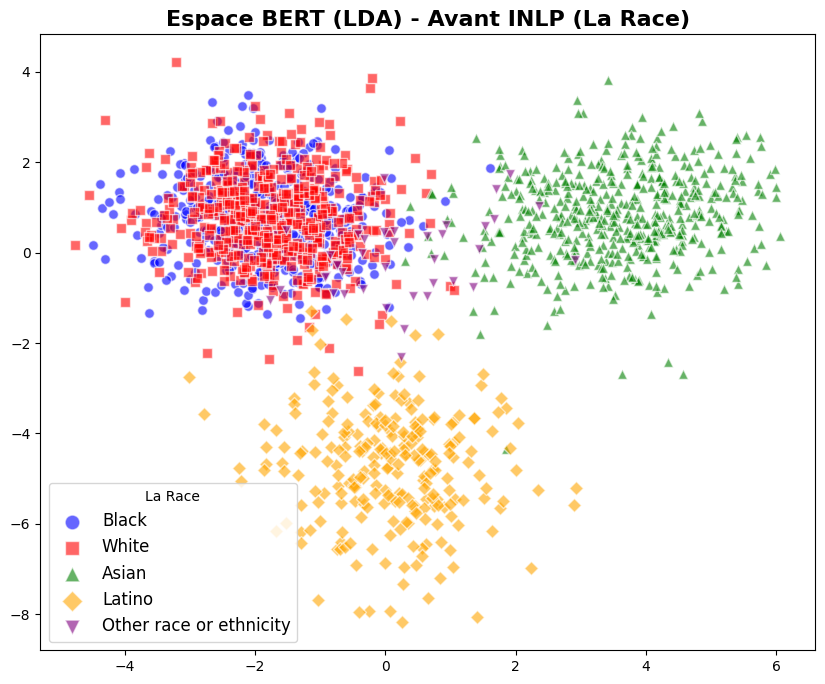


--- ÉTAPE 2 : APRÈS INLP ---
Calcul de la LDA pour 'Espace BERT (LDA) - Après INLP (La Race)'...


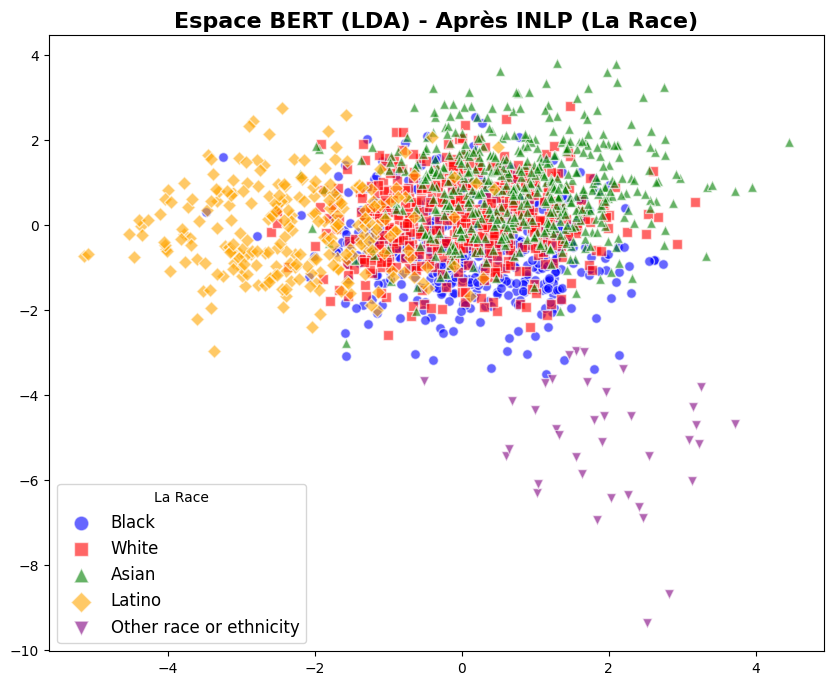

In [29]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
import matplotlib.pyplot as plt
import numpy as np

# --- 1. CRÉATION DYNAMIQUE DU MAPPING ---
colors = ['blue', 'red', 'green', 'orange', 'purple', 'brown', 'pink', 'gray', 'olive', 'cyan']
markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'h']

category_mapping = {}
for i, col in enumerate(target_cols):
    clean_name = col.replace('_', ' ').capitalize()
    category_mapping[i] = (clean_name, colors[i % len(colors)], markers[i % len(markers)])

# --- 2. FONCTION DE TRACÉ ---
def plot_lda_by_category(vecs, labels, title, mapping, legend_name="Catégorie"):
    print(f"Calcul de la LDA pour '{title}'...")
    
    lda = LDA(n_components=2)
    vecs_2d = lda.fit_transform(vecs, labels)
    
    plt.figure(figsize=(10, 8))
    unique_labels = sorted(list(set(labels.tolist())))
    
    for label in unique_labels:
        if label in mapping:
            name, color, marker = mapping[label]
            idx = (labels == label)
            
            plt.scatter(vecs_2d[idx, 0], vecs_2d[idx, 1], 
                        c=color, label=name, alpha=0.6, marker=marker, edgecolors='w', s=50)
            
    plt.legend(title=legend_name, fontsize=12, loc="best", markerscale=1.5)
    plt.title(title, fontsize=16, fontweight='bold')
    
    # MODIFICATION 1 : On ajoute le chemin vers le bon dossier !
    filename = f"{DOSSIER_ATTRIBUT}/{title.replace(' ', '_')}.png"
    plt.savefig(filename, dpi=300, bbox_inches='tight')          
    plt.show()

# --- 3. PRÉPARATION DE L'ÉCHANTILLON ---
n_per_class = 500
indices_equilibres = []
num_classes = len(target_cols) 

for label in range(num_classes):
    idx_class = np.where(z_dev_jigsaw == label)[0]
    if len(idx_class) > 0:
        choix = np.random.choice(idx_class, min(n_per_class, len(idx_class)), replace=False)
        indices_equilibres.extend(choix)

X_sample = X_dev_jigsaw[indices_equilibres]
z_sample = z_dev_jigsaw[indices_equilibres]

# --- 4. GÉNÉRATION DES GRAPHIQUES ---
# MODIFICATION 2 : Suppression de l'ancienne variable nom_categorie générique
# On utilise directement le 'nom_categorie' global ("Le Genre", "La Religion", etc.)

print("--- ÉTAPE 1 : AVANT INLP ---")
plot_lda_by_category(X_sample, z_sample, title=f"Espace BERT (LDA) - Avant INLP ({nom_categorie})", mapping=category_mapping, legend_name=nom_categorie)

X_sample_debiased = P_matrix.dot(X_sample.T).T

print("\n--- ÉTAPE 2 : APRÈS INLP ---")
plot_lda_by_category(X_sample_debiased, z_sample, title=f"Espace BERT (LDA) - Après INLP ({nom_categorie})", mapping=category_mapping, legend_name=nom_categorie)